# 03 Geo experiment - Part A: design and pre-registration
**Question:** which channel and which cities should we test, and what is the smallest effect this test can detect?

*Prakriti Foods is fictional; all data is synthetic. Everything here uses stage-1 data (weeks 1-87) only. The sealed truth has not been opened.*

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, itertools, json, matplotlib.pyplot as plt
w = pd.read_csv('../data/generated/weekly_geo.csv')
pre = w[(w.week>=36)&(w.week<=87)]
R = pre.pivot(index='week', columns='geo', values='revenue_lakh'); MS = pre.pivot(index='week', columns='geo', values='spend_Meta_lakh')
geos = list(R.columns)

## 1. Channel choice (step 3.1)
Meta: largest spend line, widest MMM v1b interval among the large channels, and the Head of Growth's case rests on its dashboard ROAS (see notebook 02). YouTube is rejected for this test: a long carry-over means an 8-week pause would give a muddy read.

## 2. Geo selection (step 3.2): match on the pre-period (weeks 36-87)
For each pair of cities, treated = the two cities combined, control = the other six combined. Score = how steadily treated and control track each other (the spread of log(treated/control) around its linear trend; lower is better), plus growth correlation, share of revenue at risk and share of Meta spend paused.

In [2]:
rows = []
for a, b in itertools.combinations(geos, 2):
    T = R[[a,b]].sum(axis=1); Cn = R.drop(columns=[a,b]).sum(axis=1)
    r = np.log(T) - np.log(Cn); x = np.arange(len(r)); res = r - np.polyval(np.polyfit(x, r, 1), x)
    rows.append((a+' + '+b, res.std(), np.corrcoef(np.diff(np.log(T)), np.diff(np.log(Cn)))[0,1], T.sum()/R.sum().sum(), MS[[a,b]].sum().sum()/MS.sum().sum()))
cand = pd.DataFrame(rows, columns=['pair','tracking_error','growth_corr','revenue_share','meta_spend_share']).sort_values('tracking_error').reset_index(drop=True)
cand.head(6).round(3)

,pair,tracking_error,growth_corr,revenue_share,meta_spend_share
0,Ahmedabad + Pune,0.060,0.477,0.141,0.138
1,Delhi NCR + Mumbai,0.060,0.502,0.378,0.385
2,Ahmedabad + Bengaluru,0.063,0.526,0.216,0.222
3,Mumbai + Pune,0.065,0.471,0.263,0.258
4,Bengaluru + Pune,0.065,0.529,0.234,0.240
5,Bengaluru + Hyderabad,0.066,0.447,0.277,0.279


**Choice: Ahmedabad + Pune.** It ties for the best tracking (0.060) with Delhi NCR + Mumbai, but pausing Meta there would put 14% of revenue at risk against 38%. Pre-registered tie-break rule: best tracking, then lowest revenue at risk. Caveat: both cities are 'newer geos' where influencers are stronger, so the result may not generalise to the big metros.

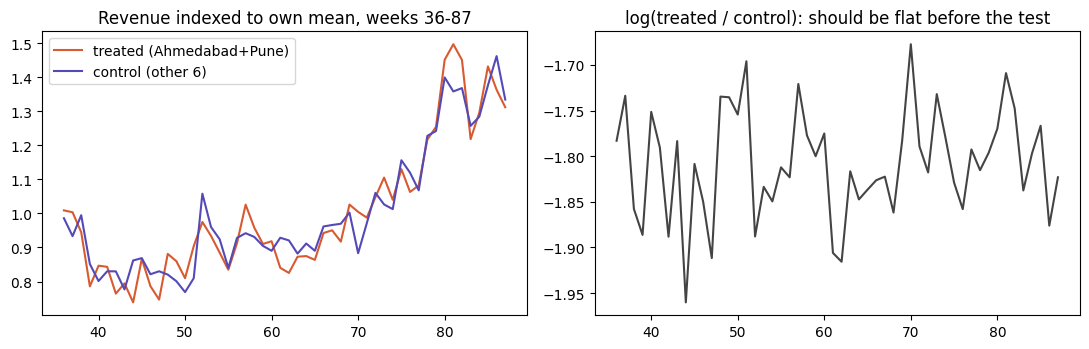

Weeks 36-87: treated geos hold 14.1% of revenue and 13.8% of Meta spend


In [3]:
A, B = 'Ahmedabad', 'Pune'; TG = [A, B]
T = R[TG].sum(axis=1); Cn = R.drop(columns=TG).sum(axis=1); r = np.log(T) - np.log(Cn)
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
ax[0].plot(T/T.mean(), label='treated (Ahmedabad+Pune)', color='#D85A30'); ax[0].plot(Cn/Cn.mean(), label='control (other 6)', color='#534AB7'); ax[0].legend(); ax[0].set_title('Revenue indexed to own mean, weeks 36-87')
ax[1].plot(r, color='#444'); ax[1].set_title('log(treated / control): should be flat before the test'); plt.tight_layout(); plt.show()
print('Weeks 36-87: treated geos hold', f'{T.sum()/R.sum().sum():.1%}', 'of revenue and', f'{MS[TG].sum().sum()/MS.sum().sum():.1%}', 'of Meta spend')

## 3. Power analysis: the smallest lift we can detect (80% power, alpha 0.05)
Method: the pre-period log-ratio series is modelled as AR(1) noise. We simulate 4,000 fake experiments (52 pre weeks, 8 test weeks), inject a revenue drop of size d into the treated cities in the test weeks, and run the difference-in-differences estimate. We cross-check against the real spread of 8-week windows inside the pre-period.

AR(1) phi = 0.11, residual SD of log ratio = 0.059
Simulated null SD of the DiD estimate: 0.025 | empirical window SD: 0.023 (25 windows)
MDE (80% power, two-sided 5%): simulation 7% drop in treated-city revenue | empirical cross-check 6%


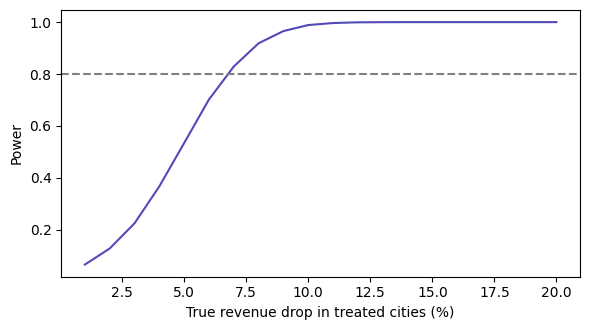

In [4]:
rs = np.random.default_rng(2026)
x = np.arange(len(r)); res = (r - np.polyval(np.polyfit(x, r, 1), x)).values
phi = np.corrcoef(res[:-1], res[1:])[0,1]; sig = res.std()
print(f'AR(1) phi = {phi:.2f}, residual SD of log ratio = {sig:.3f}')
n_sim, n_pre, n_test = 4000, 52, 8
e = rs.normal(0, sig*np.sqrt(1-phi**2), (n_sim, n_pre+n_test)); z = np.zeros_like(e); z[:,0] = rs.normal(0, sig, n_sim)
for t in range(1, n_pre+n_test): z[:,t] = phi*z[:,t-1] + e[:,t]
tau0 = z[:,n_pre:].mean(1) - z[:,:n_pre].mean(1)
crit = np.quantile(np.abs(tau0), .95)
drops = np.arange(0.01, 0.21, 0.01)
power = [np.mean(np.abs(tau0 + np.log(1-d)) > crit) for d in drops]
mde_sim = next(d for d,p in zip(drops, power) if p >= .8)
# empirical cross-check: 8-week windows inside the real pre-period, baseline = all earlier weeks (>=20)
emp = [r.iloc[s:s+8].mean() - r.iloc[:s].mean() for s in range(20, len(r)-8+1)]
mde_emp = (1.96+0.84)*np.std(emp); mde_emp_pct = 1-np.exp(-mde_emp)
print(f'Simulated null SD of the DiD estimate: {tau0.std():.3f} | empirical window SD: {np.std(emp):.3f} ({len(emp)} windows)')
print(f'MDE (80% power, two-sided 5%): simulation {mde_sim:.0%} drop in treated-city revenue | empirical cross-check {mde_emp_pct:.0%}')
plt.figure(figsize=(6,3.4)); plt.plot(drops*100, power, color='#534AB7'); plt.axhline(.8, color='grey', ls='--'); plt.xlabel('True revenue drop in treated cities (%)'); plt.ylabel('Power'); plt.tight_layout(); plt.show()

## 4. Is that detectable? What does MMM v1b expect Meta to be worth?
If Meta's true effect in the treated cities is smaller than the MDE, the test will probably return 'no effect detected'. We compare the MDE with what MMM v1b implies (its interval is wide, so this is only a plausibility check).

In [5]:
v1b = pd.read_csv('../model/mmm_v1b_roi_estimates.csv', index_col=0)
rev79 = w[w.week<=79].revenue_lakh.sum()/100
meta = v1b.loc['Meta']; spend79 = meta.spend_cr
share = lambda roi: roi*spend79/rev79
print(f"Meta's share of revenue implied by MMM v1b: mean {share(meta.ROI_mean):.0%}, 90% interval {share(meta.ROI_p5):.0%} to {share(meta.ROI_p95):.0%}")
print(f"MDE of the test: about {max(mde_sim, mde_emp_pct):.0%} (conservative). Test can only see Meta's effect if it is at least that large.")

Meta's share of revenue implied by MMM v1b: mean 10%, 90% interval 0% to 30%
MDE of the test: about 7% (conservative). Test can only see Meta's effect if it is at least that large.


## 5. Design summary (pre-registered)
| Item | Value |
|---|---|
| Channel | Meta (Facebook and Instagram) |
| Treated cities | Ahmedabad, Pune (Meta spend set to zero) |
| Control cities | the other six (Meta unchanged) |
| Test window | weeks 88-95 (8 weeks); weeks 96-104 observed as washout |
| Pre-period | weeks 36-87 |
| Primary metric | log of weekly revenue, treated vs control |
| Primary estimator | difference-in-differences |
| Secondary estimator | synthetic control (non-negative weights on the six control cities, fitted on weeks 36-87 only) |
| Inference | placebo windows in the pre-period plus the simulated AR(1) null; 90% interval |
| Calibration output | implied Meta ROI = lost revenue / Meta spend foregone, passed to MMM v2 as a lift-test prior |

In [6]:
design = {'channel':'Meta','treated_geos':TG,'control_geos':[g for g in geos if g not in TG],'weeks':[88,95],'pre_period':[36,87],
          'primary_estimator':'DiD on log revenue','secondary_estimator':'synthetic control','alpha':0.05,'mde_pct_conservative':round(100*max(mde_sim, mde_emp_pct),1)}
json.dump(design, open('../preregistration/design.json','w'), indent=2); design

{'channel': 'Meta',
 'treated_geos': ['Ahmedabad', 'Pune'],
 'control_geos': ['Bengaluru',
  'Chennai',
  'Delhi NCR',
  'Hyderabad',
  'Kolkata',
  'Mumbai'],
 'weeks': [88, 95],
 'pre_period': [36, 87],
 'primary_estimator': 'DiD on log revenue',
 'secondary_estimator': 'synthetic control',
 'alpha': 0.05,
 'mde_pct_conservative': np.float64(7.0)}

## Answer
Test Meta by pausing it in Ahmedabad and Pune for weeks 88-95. The test can detect a drop in treated-city revenue of about 7% or more (80% power, 5% two-sided); a simulation gives 7% and a check on real pre-period windows gives 6%. MMM v1b implies Meta is worth about 10% of revenue, but with a 90% interval of 0% to 30%. So the test is adequately powered if Meta is worth 10% or more, and will probably miss it if Meta is worth 5%. A null result would be informative too: it would say Meta's effect is below about 7% in these cities. Pre-registration is in `preregistration/design.md` and must be committed before stage 2 is generated.

---
# Part B: experiment readout (stage 2 data, weeks 1-104)
**Question:** did pausing Meta in Ahmedabad and Pune lower their revenue, by how much, and what ROI does that imply?

This follows `preregistration/design.md` exactly. Details the pre-registration left open are fixed here, before looking at results, and listed in the final cell. Stage-2 data were generated by the pre-registered design; weeks 1-87 are verified identical to stage 1 (`data/continuity_check.txt`).

In [7]:
from scipy.optimize import minimize
w2 = pd.read_csv('../data/stage2/weekly_geo.csv')
R2 = w2.pivot(index='week', columns='geo', values='revenue_lakh'); MS2 = w2.pivot(index='week', columns='geo', values='spend_Meta_lakh')
CG = design['control_geos']
Tt = R2[TG].sum(axis=1); Cc = R2[CG].sum(axis=1); lr = np.log(Tt) - np.log(Cc)
PRE, TEST, POST = range(36, 88), range(88, 96), range(96, 105)
print('Meta spend in treated cities, weeks 88-95:', round(MS2.loc[88:95, TG].sum().sum(), 2), 'lakh (should be 0) | control cities:', round(MS2.loc[88:95, CG].sum().sum(), 1), 'lakh')

Meta spend in treated cities, weeks 88-95: 0.0 lakh (should be 0) | control cities: 136.4 lakh


## 1. Pre-period fit (did treated and control move together before the test?)

Pre-period log(treated/control): mean -1.808, SD 0.059 (weeks 36-87)


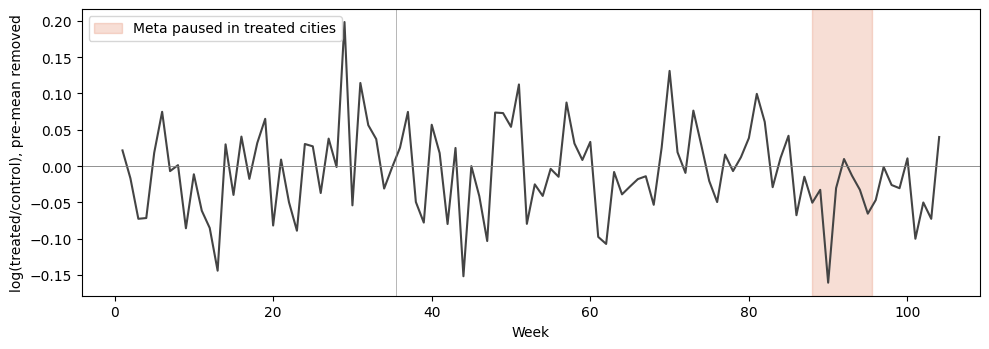

In [8]:
x = np.arange(len(PRE)); pre_r = lr.loc[36:87].values
print(f'Pre-period log(treated/control): mean {pre_r.mean():.3f}, SD {pre_r.std():.3f} (weeks 36-87)')
fig, ax = plt.subplots(figsize=(10,3.6)); ax.plot(lr.index, lr.values - pre_r.mean(), color='#444')
ax.axvspan(88, 95.5, color='#D85A30', alpha=.2, label='Meta paused in treated cities'); ax.axhline(0, color='grey', lw=.6); ax.axvline(35.5, color='grey', lw=.4)
ax.set_xlabel('Week'); ax.set_ylabel('log(treated/control), pre-mean removed'); ax.legend(); plt.tight_layout(); plt.show()

## 2. Primary estimate: difference-in-differences

In [9]:
tau = lr.loc[88:95].mean() - lr.loc[36:87].mean()
print(f'DiD tau (log points): {tau:.4f}  ->  treated-city revenue change vs control: {np.expm1(tau):.1%}')

DiD tau (log points): -0.0470  ->  treated-city revenue change vs control: -4.6%


## 3. Uncertainty (pre-registered: placebo windows and simulated AR(1) null)

In [10]:
crit90_sim = np.quantile(np.abs(tau0), .90); crit95_sim = np.quantile(np.abs(tau0), .95)
sd_emp = np.std(emp); crit90_emp, crit95_emp = 1.645*sd_emp, 1.96*sd_emp
c90, c95 = max(crit90_sim, crit90_emp), max(crit95_sim, crit95_emp)    # use the wider (more conservative)
print(f'90% half-width: simulated {crit90_sim:.4f}, empirical windows {crit90_emp:.4f} -> using {c90:.4f}')
print(f'tau 90% interval: [{tau-c90:.4f}, {tau+c90:.4f}]  =  revenue change [{np.expm1(tau-c90):.1%}, {np.expm1(tau+c90):.1%}]')
print(f'tau 95% interval: [{tau-c95:.4f}, {tau+c95:.4f}]  =  revenue change [{np.expm1(tau-c95):.1%}, {np.expm1(tau+c95):.1%}]')
print('90% interval excludes zero:', (tau+c90 < 0) or (tau-c90 > 0))

90% half-width: simulated 0.0404, empirical windows 0.0386 -> using 0.0404
tau 90% interval: [-0.0875, -0.0066]  =  revenue change [-8.4%, -0.7%]
tau 95% interval: [-0.0955, 0.0014]  =  revenue change [-9.1%, 0.1%]
90% interval excludes zero: True


## 4. Placebo checks (same DiD in three windows where nothing happened)

In [11]:
for s,e in [(64,71),(72,79),(80,87)]:
    t_ = lr.loc[s:e].mean() - lr.loc[36:s-1].mean()
    print(f'placebo weeks {s}-{e}: tau {t_:+.4f} ({np.expm1(t_):+.1%})  inside +/- {c90:.3f}: {abs(t_)<c90}')

placebo weeks 64-71: tau +0.0103 (+1.0%)  inside +/- 0.040: True


placebo weeks 72-79: tau +0.0110 (+1.1%)  inside +/- 0.040: True
placebo weeks 80-87: tau +0.0207 (+2.1%)  inside +/- 0.040: True


## 5. Secondary estimate: synthetic control (non-negative weights summing to 1 on the six control cities, fitted on weeks 36-87)

Weights: {'Bengaluru': np.float64(0.0), 'Chennai': np.float64(0.31), 'Delhi NCR': np.float64(0.21), 'Hyderabad': np.float64(0.21), 'Kolkata': np.float64(0.09), 'Mumbai': np.float64(0.19)}
Pre-period gap SD: synthetic control 0.0569 vs simple control sum 0.0594
Synthetic-control tau: -0.0491  ->  -4.8%  (DiD: -4.6%)


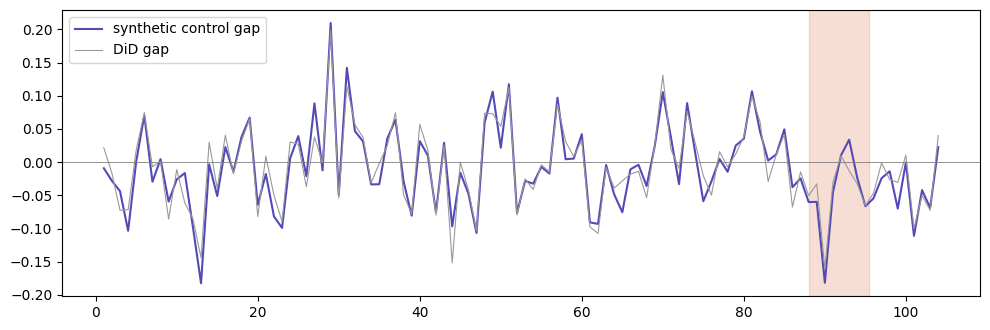

In [12]:
Xc = R2.loc[36:87, CG].values; yt = Tt.loc[36:87].values
f = lambda wv: np.sum((np.log(yt) - np.log(Xc @ wv))**2)
res = minimize(f, np.ones(6)/6, bounds=[(0,1)]*6, constraints={'type':'eq','fun':lambda wv: wv.sum()-1}, method='SLSQP')
wv = res.x; syn = pd.Series(R2[CG].values @ wv, index=R2.index)
gap = np.log(Tt) - np.log(syn); tau_sc = gap.loc[88:95].mean() - gap.loc[36:87].mean()
print('Weights:', dict(zip(CG, wv.round(2))))
print(f'Pre-period gap SD: synthetic control {gap.loc[36:87].std():.4f} vs simple control sum {pre_r.std():.4f}')
print(f'Synthetic-control tau: {tau_sc:.4f}  ->  {np.expm1(tau_sc):.1%}  (DiD: {np.expm1(tau):.1%})')
fig, ax = plt.subplots(figsize=(10,3.4)); ax.plot(gap - gap.loc[36:87].mean(), color='#534AB7', label='synthetic control gap'); ax.plot(lr - pre_r.mean(), color='#999', lw=.8, label='DiD gap')
ax.axvspan(88, 95.5, color='#D85A30', alpha=.2); ax.axhline(0, color='grey', lw=.6); ax.legend(); plt.tight_layout(); plt.show()

## 6. Implied Meta ROI and washout

In [13]:
spend_foregone = MS2.loc[80:87, TG].sum(axis=1).mean() * 8
Ttest = Tt.loc[88:95].sum()
def roi_of(tau_):                       # lost revenue = counterfactual - actual, counterfactual = actual * exp(-tau)
    return (Ttest*np.exp(-tau_) - Ttest) / spend_foregone
roi_pt, roi_lo, roi_hi = roi_of(tau), roi_of(tau + c90), roi_of(tau - c90)   # more negative tau => larger loss => higher ROI
print(f'Meta spend foregone (mean weekly weeks 80-87 x 8): Rs {spend_foregone:.1f} lakh')
print(f'Revenue lost in treated cities weeks 88-95: Rs {Ttest*np.exp(-tau)-Ttest:.1f} lakh (point), implied ROI {roi_pt:.2f} (90% interval {roi_lo:.2f} to {roi_hi:.2f})')
roi_sc = roi_of(tau_sc); print(f'Synthetic-control implied ROI: {roi_sc:.2f}')
print('Washout: mean gap weeks 96-104 vs pre:', f'{lr.loc[96:104].mean() - lr.loc[36:87].mean():+.4f}', '(a return toward 0 would mean the effect was caused by the pause)')

Meta spend foregone (mean weekly weeks 80-87 x 8): Rs 25.7 lakh
Revenue lost in treated cities weeks 88-95: Rs 16.0 lakh (point), implied ROI 0.62 (90% interval 0.09 to 1.18)
Synthetic-control implied ROI: 0.65
Washout: mean gap weeks 96-104 vs pre: -0.0308 (a return toward 0 would mean the effect was caused by the pause)


## 7. Compare with MMM v1b and the platform dashboard (step 4.3)

In [14]:
v1b = pd.read_csv('../model/mmm_v1b_roi_estimates.csv', index_col=0).loc['Meta']
plat = pd.read_csv('../data/stage2/platform_reported.csv'); pm = plat[(plat.channel=='Meta')&(plat.week<=87)]
roas = pm.platform_revenue_lakh.sum()/pm.spend_lakh.sum()
cmp_ = pd.DataFrame({'Meta ROI': [roas, v1b.ROI_mean, roi_pt, roi_sc], 'low (90%)': [np.nan, v1b.ROI_p5, roi_lo, np.nan], 'high (90%)': [np.nan, v1b.ROI_p95, roi_hi, np.nan]},
   index=['Platform-reported ROAS (wks 1-87)', 'MMM v1b (wks 1-79)', 'Geo experiment, DiD', 'Geo experiment, synthetic control']).round(2)
cmp_

,Meta ROI,low (90%),high (90%)
Platform-reported ROAS (wks 1-87),3.03,NaN,NaN
MMM v1b (wks 1-79),1.61,0.07,4.63
"Geo experiment, DiD",0.62,0.09,1.18
"Geo experiment, synthetic control",0.65,NaN,NaN


## Details fixed here that design.md left open (set before looking at results)
- Placebo windows: the last three non-overlapping 8-week windows of the pre-period (weeks 64-71, 72-79, 80-87), baseline = weeks 36 up to the window start.
- Interval: the wider of the simulated-AR(1) and empirical-window half-widths, so the interval is conservative.
- Synthetic control fitted on log revenue by least squares; effect measured as the post gap minus the pre-period mean gap.
- Counterfactual revenue = actual treated revenue x exp(-tau).

## 8. EXPLORATORY (not pre-registered): is there drift in the pre-period?
All three placebo windows came out positive, which suggests treated cities were slowly gaining on control before the test. The pre-registered DiD assumes a flat pre-period, so drift would bias it toward zero. This check extrapolates the pre-period trend instead. It is reported as a sensitivity analysis only; the pre-registered result stays the headline.

In [15]:
xx = np.arange(36, 88); slope, icpt = np.polyfit(xx, lr.loc[36:87].values, 1)
tau_tr = (lr.loc[88:95].values - (icpt + slope*np.arange(88, 96))).mean()
print(f'Pre-period drift: {slope*52:+.3f} log points per year (t-stat vs zero is only suggestive with 52 noisy weeks)')
print(f'Trend-adjusted tau (exploratory): {tau_tr:.4f} -> {np.expm1(tau_tr):.1%}  (pre-registered DiD: {np.expm1(tau):.1%})')
print(f'Implied ROI under trend adjustment (exploratory): {roi_of(tau_tr):.2f}')

Pre-period drift: +0.025 log points per year (t-stat vs zero is only suggestive with 52 noisy weeks)
Trend-adjusted tau (exploratory): -0.0613 -> -5.9%  (pre-registered DiD: -4.6%)
Implied ROI under trend adjustment (exploratory): 0.82


## Answer
- **Result (pre-registered):** pausing Meta in Ahmedabad and Pune lowered their revenue by about 4.6% relative to control (90% interval -8.4% to -0.7%; the 95% interval just reaches +0.1%). Synthetic control agrees (-4.8%). All three placebo windows fall inside the noise band.
- **Implied Meta ROI: about 0.6 (90% interval 0.1 to 1.2)**, against 3.0 on the platform dashboard and 1.6 in MMM v1b (interval 0.07 to 4.6). The experiment interval is about a quarter of the width of the MMM's and sits inside it.
- **Decision rule outcome:** the 90% interval excludes zero, so the implied ROI and its interval go into MMM v2 as a lift-test calibration input.
- **Cautions I would not hide:** (1) the effect is smaller than the 7% minimum detectable effect, so a result that clears significance at this size is likely an overestimate of the true effect's precision (winner's curse); the 95% interval touches zero. (2) All placebo windows are positive, so the pre-period is drifting and the DiD may understate the drop (section 8, exploratory). (3) The gap did not return to zero in weeks 96-104 (-3.1%), but that is within noise for a 9-week mean, so the washout is inconclusive. (4) Only two cities, both newer geos. Whether this ROI matches the planted truth is not known; that is graded in Phase 6.